Projeto Final - Business Intelligence
Análise Exploratória de Dados de Recursos Humanos (HR)
Aluno: Luís Oliveira

Neste projeto são aplicadas técnicas de SQL, Python e Análise Exploratória de Dados (EDA) para investigar a estrutura de Recursos Humanos da base HR, transformando dados em informações úteis para apoio à tomada de decisão.

In [ ]:
# importando as bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Carregar os arquivos CSV

df_query1 = pd.read_csv("../dados/sql_1.csv")
df_query2 = pd.read_csv("../dados/sql_2.csv")

In [ ]:
# Primeiras linhas da Query 1 para verificar se os dados foram carregados corretamente

df_query1.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,JOB_TITLE,DEPARTMENT_NAME,SALARY,HIRE_DATE
0,205,Shelley,Higgins,Accounting Manager,Accounting,12008,2012-06-07T00:00:00Z
1,206,William,Gietz,Public Accountant,Accounting,8300,2012-06-07T00:00:00Z
2,200,Jennifer,Whalen,Administration Assistant,Administration,4400,2013-09-17T00:00:00Z
3,100,Steven,King,President,Executive,24000,2013-06-17T00:00:00Z
4,101,Neena,Yang,Administration Vice President,Executive,17000,2015-09-21T00:00:00Z


In [ ]:
# Verificando o número de linhas e colunas da Query 1

print("Query 1:", df_query1.shape)

Query 1: (106, 7)


In [ ]:
# Verificando a estrutura do DataFrame da Query 1

df_query1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   EMPLOYEE_ID      106 non-null    int64              
 1   FIRST_NAME       106 non-null    object             
 2   LAST_NAME        106 non-null    object             
 3   JOB_TITLE        106 non-null    object             
 4   DEPARTMENT_NAME  106 non-null    object             
 5   SALARY           106 non-null    int64              
 6   HIRE_DATE        106 non-null    datetime64[ns, UTC]
 7   ANO_CONTRATACAO  106 non-null    int32              
 8   MES_CONTRATACAO  106 non-null    int32              
 9   TEMPO_EMPRESA    106 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(1), int32(2), int64(2), object(4)
memory usage: 7.6+ KB


In [ ]:
# Levantamento Estatístico da coluna salário

df_query1["SALARY"].describe()

count      106.000000
mean      6456.754717
std       3927.798234
min       2100.000000
25%       3100.000000
50%       6150.000000
75%       8950.000000
max      24000.000000
Name: SALARY, dtype: float64

Análise Prévia:

Quantidade de funcionários existentes na base: count = 106

Salário médio: mean = 6456,75

Isso significa que, se somarmos todos os salários e dividirmos por 106, teremos aproximadamente R$ 6.456,75.

Mediana: 50% = 6150, a mediana é o salário que fica exatamente no meio da distribuição, ou seja, :

Metade dos funcionários possui salário igual ou inferior à mediana, e a outra metade possui salário igual ou superior à mediana

Comparação:  Média   = R$ 6.456,75 
             Mediana = R$ 6.150,00

A média é um pouco maior que a mediana, sugerindo que existem alguns salários elevados puxando a média para cima.

Menor salário: 2100, existe pelo menos um funcionário recebendo R$ 2.100.

Maior salário: 24000, O maior salário é R$ 24.000.

Análise comparativa: 24000 ÷ 2100 ≈ 11,4, o maior salário é cerca de 11 vezes maior que o menor.

Isso mostra uma amplitude salarial significativa entre os cargos da empresa.

Quartis
25% = 3100
50% = 6150
75% = 8950

Isso significa que: 

25% dos funcionários recebem até R$ 3.100.
50% recebem até R$ 6.150.
75% recebem até R$ 8.950.

Consequentemente, apenas 25% dos funcionários recebem mais de R$ 8.950.

Desvio padrão: 3927,79, o desvio padrão mede o quanto os salários variam em relação à média.

Um valor de quase R$ 4.000 indica uma dispersão considerável, o que faz sentido em uma empresa que possui cargos operacionais, gerenciais e executivos.

Conclusão da análise

A empresa possui 106 funcionários. O salário médio é de R$ 6.456,75, enquanto a mediana é de R$ 6.150,00, indicando que alguns salários mais elevados aumentam a média geral. A remuneração varia de R$ 2.100,00 a R$ 24.000,00, evidenciando uma ampla faixa salarial compatível com diferentes níveis hierárquicos.

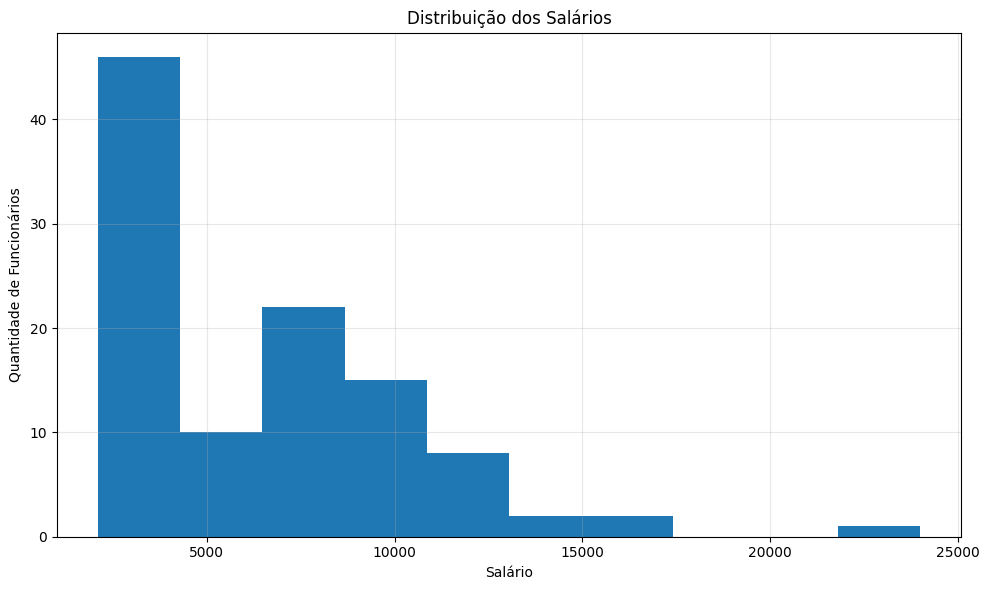

In [60]:
# Visualização da distribuição dos salários

plt.figure(figsize=(10,6))

plt.hist(df_query1["SALARY"], bins=10)

plt.title("Distribuição dos Salários")
plt.xlabel("Salário")
plt.ylabel("Quantidade de Funcionários")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../graficos/distribuicao_salarios.png", dpi=300, bbox_inches="tight")

plt.show()

In [61]:
# Salário médio por departamento

salario_departamento = (df_query1.groupby("DEPARTMENT_NAME")["SALARY"].mean().sort_values(ascending=False))

salario_departamento

DEPARTMENT_NAME
Executive           19333.333333
Accounting          10154.000000
Public Relations    10000.000000
Marketing            9500.000000
Sales                8955.882353
Finance              8601.333333
Human Resources      6500.000000
IT                   5760.000000
Administration       4400.000000
Purchasing           4150.000000
Shipping             3475.555556
Name: SALARY, dtype: float64

Análise Prévia

O departamento Executive apresentou a maior média salarial (R$ 19.333), refletindo a presença de cargos estratégicos e de alta responsabilidade, como presidente e vice-presidentes.

O departamento Shipping apresentou a menor média salarial (R$ 3.475), indicando predominância de funções operacionais.

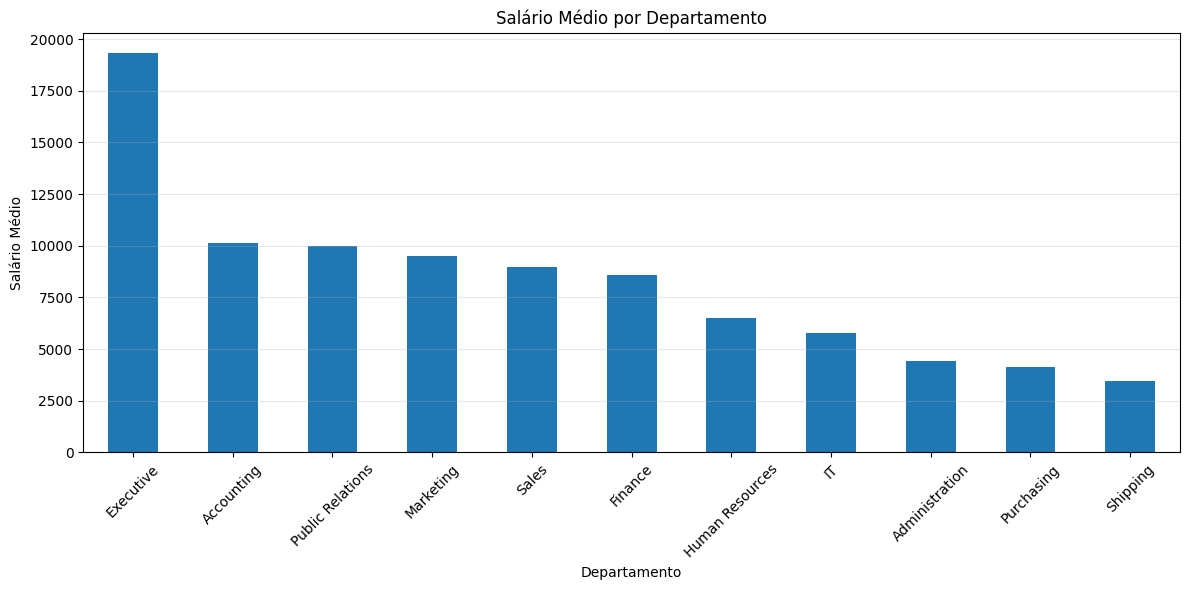

In [62]:
# Média salarial por departamento

salario_departamento = (df_query1.groupby("DEPARTMENT_NAME")["SALARY"].mean().sort_values(ascending=False))

plt.figure(figsize=(12,6))

salario_departamento.plot(kind="bar")

plt.title("Salário Médio por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../graficos/salario_medio_departamento.png",dpi=300,bbox_inches="tight")

plt.show()

O que eu investigaria a partir desse gráfico?

Investigação 1

O Executive tem uma média muito alta.

P: Existem poucos funcionários com salários extremamente altos ou todos recebem bem?


Investigação 2

P: Por que Shipping paga tão pouco?

Será que:   possui muitos funcionários iniciantes?
            concentra cargos operacionais?
            está dentro da política salarial?


Investigação 3

Sales possui uma média alta.

Mas será que:   todos recebem bem?
                ou poucos vendedores ganham muito por comissão?

In [63]:
# Quantidade de funcionários por departamento

funcionarios_departamento = (df_query1["DEPARTMENT_NAME"].value_counts())

funcionarios_departamento

DEPARTMENT_NAME
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Accounting           2
Marketing            2
Administration       1
Human Resources      1
Public Relations     1
Name: count, dtype: int64

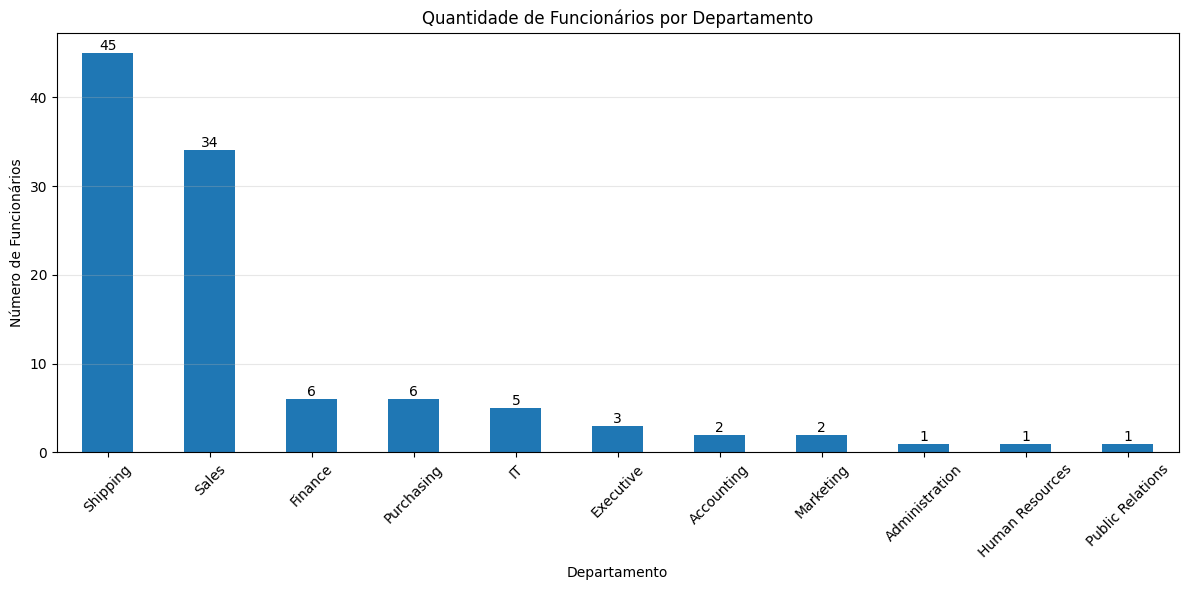

In [64]:
# Quantidade de funcionários por departamento

funcionarios_departamento = (df_query1["DEPARTMENT_NAME"].value_counts())

plt.figure(figsize=(12,6))

ax = funcionarios_departamento.plot(kind="bar")

plt.title("Quantidade de Funcionários por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Número de Funcionários")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

# Adiciona os valores sobre cada barra

for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{int(altura)}',(barra.get_x() + barra.get_width()/2, altura),ha='center',va='bottom',fontsize=10) 

plt.tight_layout()

plt.savefig("../graficos/quantidade_funcionarios_departamento.png",dpi=300,bbox_inches="tight")

plt.show()

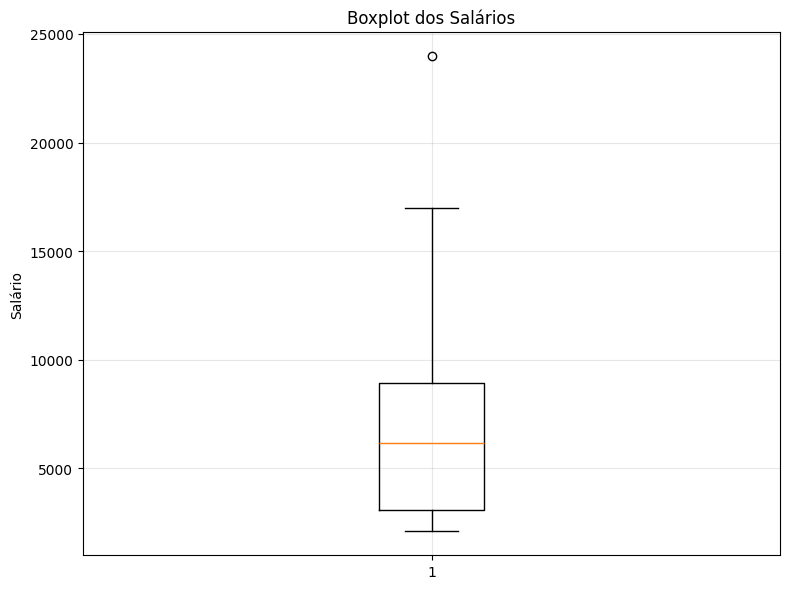

In [65]:
# Boxplot dos salários

plt.figure(figsize=(8,6))

plt.boxplot(df_query1["SALARY"], vert=True)

plt.title("Boxplot dos Salários")
plt.ylabel("Salário")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../graficos/boxplot_salarios.png",dpi=300,bbox_inches="tight") 

plt.show()

O boxplot apresenta uma visão resumida da distribuição dos salários de todos os colaboradores da empresa, permitindo identificar a mediana, a dispersão dos dados e a presença de possíveis valores atípicos (outliers).

Observa-se que a mediana salarial está próxima de US$ 6.150, indicando que metade dos funcionários recebe salários abaixo desse valor e a outra metade recebe salários iguais ou superiores.

A caixa do boxplot (intervalo entre o primeiro e o terceiro quartil) concentra aproximadamente 50% dos salários da empresa, situando-se entre US$ 3.100 e US$ 8.950. Isso demonstra que a maior parte dos colaboradores está concentrada nessa faixa de remuneração.

Os limites superiores e inferiores (bigodes) mostram a variação considerada esperada para os salários. Acima do limite superior observa-se a presença de um outlier, representando um colaborador com remuneração significativamente superior aos demais.

Esse valor extremo corresponde ao maior salário da empresa (US$ 24.000), provavelmente associado a um cargo executivo de alto nível. A existência desse outlier ajuda a explicar por que a média salarial (US$ 6.456,75) é superior à mediana (US$ 6.150,00), uma vez que salários elevados exercem influência direta sobre o cálculo da média.

Conclusão

O boxplot confirma que a empresa possui uma distribuição salarial assimétrica, com concentração de colaboradores nas faixas de menor remuneração e poucos profissionais recebendo salários muito elevados. Esse comportamento é característico de organizações com estrutura hierárquica bem definida, nas quais um número reduzido de cargos estratégicos apresenta remuneração significativamente superior à maior parte dos colaboradores.

In [66]:
# Análise de Departamentos

departamentos = (
    df_query1["DEPARTMENT_NAME"]
    .value_counts()
    .reset_index()
)

departamentos.columns = ["Departamento", "Funcionários"]

departamentos["Percentual"] = (departamentos["Funcionários"] / departamentos["Funcionários"].sum() * 100).round(1)

departamentos

,Departamento,Funcionários,Percentual
0,Shipping,45,42.5
1,Sales,34,32.1
2,Finance,6,5.7
3,Purchasing,6,5.7
4,IT,5,4.7
5,Executive,3,2.8
6,Accounting,2,1.9
7,Marketing,2,1.9
8,Administration,1,0.9
9,Human Resources,1,0.9


Análise prévia

O departamento Shipping concentra a maior quantidade de funcionários, porém apresenta uma das menores médias salariais. Isso sugere que a área é composta predominantemente por cargos operacionais ou de menor complexidade. 

P: O RH poderia comparar essa remuneração com a média de mercado para avaliar se ela continua competitiva e se há risco de rotatividade?

Em contrapartida, departamentos com funções estratégicas ou gerenciais possuem menos colaboradores, mas apresentam médias salariais significativamente superiores

In [ ]:
# Levantamento Estatístico da base de dados

print("=" * 40)
print("RESUMO DA BASE")
print("=" * 40)

print(f"Total de funcionários: {len(df_query1)}")
print(f"Salário médio: R$ {df_query1['SALARY'].mean():,.2f}")
print(f"Mediana salarial: R$ {df_query1['SALARY'].median():,.2f}")
print(f"Menor salário: R$ {df_query1['SALARY'].min():,.2f}")
print(f"Maior salário: R$ {df_query1['SALARY'].max():,.2f}")

RESUMO DA BASE
Total de funcionários: 106
Salário médio: R$ 6,456.75
Mediana salarial: R$ 6,150.00
Menor salário: R$ 2,100.00
Maior salário: R$ 24,000.00


In [ ]:
# Primeiras linhas da Query 2

df_query2.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,CITY,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
0,201,Michael,Martinez,13000,Marketing,Toronto,Ontario,Canada,Americas
1,202,Pat,Davis,6000,Marketing,Toronto,Ontario,Canada,Americas
2,100,Steven,King,24000,Executive,Seattle,Washington,United States of America,Americas
3,101,Neena,Yang,17000,Executive,Seattle,Washington,United States of America,Americas
4,102,Lex,Garcia,17000,Executive,Seattle,Washington,United States of America,Americas


In [ ]:
# Verificando o número de linhas e colunas da Query 2

print("Query 2:", df_query2.shape)

Query 2: (106, 9)


In [ ]:
# Verificando a estrutura do DataFrame da Query 2

df_query2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      106 non-null    int64 
 1   FIRST_NAME       106 non-null    object
 2   LAST_NAME        106 non-null    object
 3   SALARY           106 non-null    int64 
 4   DEPARTMENT_NAME  106 non-null    object
 5   CITY             106 non-null    object
 6   STATE_PROVINCE   105 non-null    object
 7   COUNTRY_NAME     106 non-null    object
 8   REGION_NAME      106 non-null    object
dtypes: int64(2), object(7)
memory usage: 7.6+ KB


In [ ]:
# Média salarial por cargo

salario_cargo = (df_query1.groupby("JOB_TITLE")["SALARY"].mean().sort_values(ascending=False))

salario_cargo

JOB_TITLE
President                          24000.000000
Administration Vice President      17000.000000
Marketing Manager                  13000.000000
Sales Manager                      12200.000000
Finance Manager                    12008.000000
Accounting Manager                 12008.000000
Purchasing Manager                 11000.000000
Public Relations Representative    10000.000000
Sales Representative                8396.551724
Public Accountant                   8300.000000
Accountant                          7920.000000
Stock Manager                       7280.000000
Human Resources Representative      6500.000000
Marketing Representative            6000.000000
Programmer                          5760.000000
Administration Assistant            4400.000000
Shipping Clerk                      3215.000000
Stock Clerk                         2785.000000
Purchasing Clerk                    2780.000000
Name: SALARY, dtype: float64

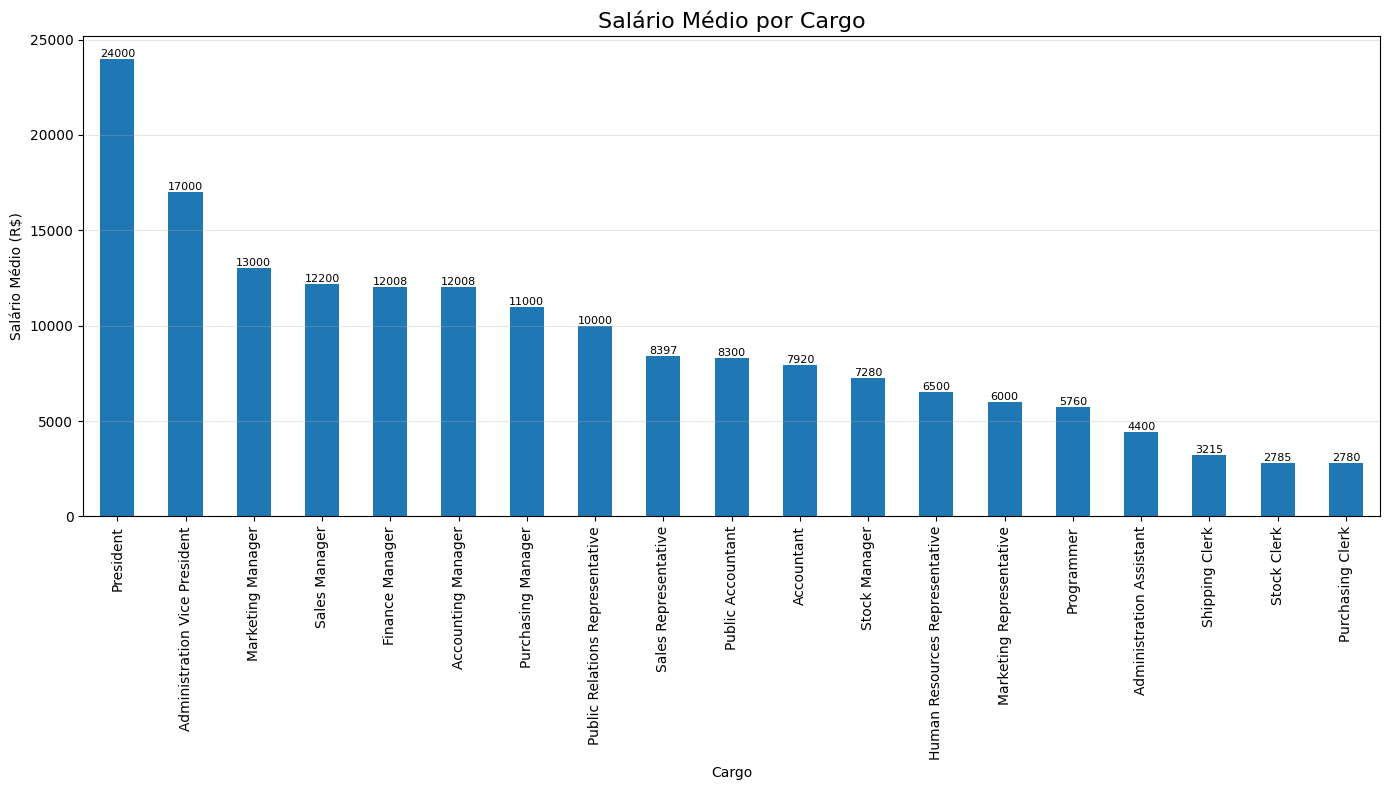

In [ ]:
# Gráfico - Salário Médio por Cargo

plt.figure(figsize=(14,8))

ax = salario_cargo.plot(kind="bar")

plt.title("Salário Médio por Cargo", fontsize=16)
plt.xlabel("Cargo")
plt.ylabel("Salário Médio (R$)")

plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)

# Valores acima das barras
for barra in ax.patches:
    altura = barra.get_height()

    ax.annotate(f'{altura:.0f}',(barra.get_x() + barra.get_width()/2, altura),ha='center',va='bottom',fontsize=8)   

plt.tight_layout()

plt.savefig("../graficos/salario_medio_cargo.png",dpi=300,bbox_inches="tight")

plt.show()

<Figure size 1600x800 with 0 Axes>

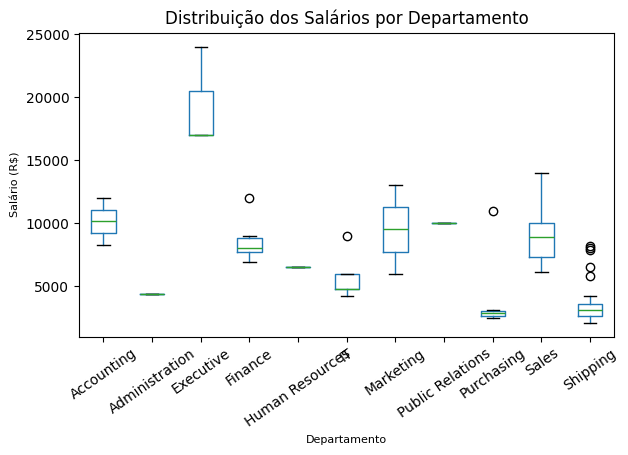

In [ ]:
# Boxplot - Distribuição dos Salários por Departamento

plt.figure(figsize=(16,8))

df_query1.boxplot(column="SALARY",by="DEPARTMENT_NAME",grid=False,rot=35)

plt.title("Distribuição dos Salários por Departamento")
plt.suptitle("")  # Remove o título automático do Pandas
plt.xlabel("Departamento", fontsize=8)
plt.ylabel("Salário (R$)", fontsize=8)

plt.tight_layout()

plt.savefig("../graficos/salario_departamento.png",dpi=300,bbox_inches="tight") 

plt.show()


O boxplot dos salários por departamento foi utilizado para comparar a distribuição da remuneração entre as diferentes áreas da empresa, permitindo analisar não apenas a média, mas também a mediana, a dispersão dos salários e a presença de valores atípicos (outliers).

Observa-se que o departamento Executive apresenta os maiores salários da organização, com remunerações concentradas em uma faixa elevada e pouca variação entre seus ocupantes. Esse comportamento é esperado, uma vez que o departamento é composto por cargos estratégicos de alta responsabilidade.

Os departamentos Sales e Marketing apresentam maior dispersão salarial, evidenciada pela amplitude das caixas e dos bigodes do boxplot. Essa característica indica a existência de diferentes níveis hierárquicos dentro dessas áreas, reunindo profissionais com níveis de experiência e responsabilidade distintos, como analistas, especialistas, supervisores e gerentes.

O departamento Shipping possui uma das menores medianas salariais, porém apresenta diversos outliers. Esses pontos representam colaboradores com remuneração significativamente superior à maioria dos funcionários do departamento, sugerindo a presença de cargos de supervisão ou coordenação em uma área predominantemente operacional.

Alguns departamentos, como Administration, Human Resources e Public Relations, apresentam pouca dispersão salarial. Isso pode ser explicado pelo reduzido número de colaboradores ou por estruturas hierárquicas menos diversificadas, nas quais os salários permanecem relativamente homogêneos.

De forma geral, o boxplot evidencia que a política salarial da empresa acompanha sua estrutura organizacional. Departamentos estratégicos concentram remunerações mais elevadas, enquanto áreas operacionais apresentam salários menores, porém com exceções relacionadas a cargos de liderança.

Conclusão

A análise do boxplot demonstra que utilizar apenas a média salarial não seria suficiente para compreender a estrutura de remuneração da empresa. A visualização permitiu identificar diferenças de dispersão entre departamentos, detectar outliers e compreender como a composição hierárquica de cada área influencia a distribuição dos salários. Dessa forma, o boxplot complementa a análise descritiva e fornece uma visão mais completa da política de remuneração da organização.




In [ ]:
# Analisando o departamento de Public Relations

df_query1[df_query1["DEPARTMENT_NAME"] == "Public Relations"]

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,JOB_TITLE,DEPARTMENT_NAME,SALARY,HIRE_DATE
20,204,Hermann,Brown,Public Relations Representative,Public Relations,10000,2012-06-07T00:00:00Z


In [68]:
# Convertendo a coluna HIRE_DATE para o tipo datetime

df_query1["HIRE_DATE"] = pd.to_datetime(df_query1["HIRE_DATE"])

df_query1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   EMPLOYEE_ID      106 non-null    int64              
 1   FIRST_NAME       106 non-null    object             
 2   LAST_NAME        106 non-null    object             
 3   JOB_TITLE        106 non-null    object             
 4   DEPARTMENT_NAME  106 non-null    object             
 5   SALARY           106 non-null    int64              
 6   HIRE_DATE        106 non-null    datetime64[ns, UTC]
 7   ANO_CONTRATACAO  106 non-null    int32              
 8   MES_CONTRATACAO  106 non-null    int32              
 9   TEMPO_EMPRESA    106 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(1), int32(2), int64(2), object(4)
memory usage: 7.6+ KB


In [69]:
# Extraindo informações de data da coluna HIRE_DATE

# Ano da contratação
df_query1["ANO_CONTRATACAO"] = df_query1["HIRE_DATE"].dt.year

# Mês da contratação
df_query1["MES_CONTRATACAO"] = df_query1["HIRE_DATE"].dt.month

# Tempo de empresa (anos)
hoje = pd.Timestamp.today(tz="UTC")

df_query1["TEMPO_EMPRESA"] = ((hoje - df_query1["HIRE_DATE"]).dt.days / 365.25).round(1)
df_query1.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,JOB_TITLE,DEPARTMENT_NAME,SALARY,HIRE_DATE,ANO_CONTRATACAO,MES_CONTRATACAO,TEMPO_EMPRESA
0,205,Shelley,Higgins,Accounting Manager,Accounting,12008,2012-06-07 00:00:00+00:00,2012,6,14.1
1,206,William,Gietz,Public Accountant,Accounting,8300,2012-06-07 00:00:00+00:00,2012,6,14.1
2,200,Jennifer,Whalen,Administration Assistant,Administration,4400,2013-09-17 00:00:00+00:00,2013,9,12.8
3,100,Steven,King,President,Executive,24000,2013-06-17 00:00:00+00:00,2013,6,13.1
4,101,Neena,Yang,Administration Vice President,Executive,17000,2015-09-21 00:00:00+00:00,2015,9,10.8


In [ ]:
# Estatísticas descritivas da coluna TEMPO_EMPRESA

df_query1["TEMPO_EMPRESA"].describe()

count    106.000000
mean      10.698113
std        1.628203
min        8.200000
25%        9.400000
50%       10.550000
75%       11.475000
max       15.500000
Name: TEMPO_EMPRESA, dtype: float64

In [70]:
# Funcionários mais antigos da empresa

funcionarios_antigos = (df_query1[["FIRST_NAME","LAST_NAME","DEPARTMENT_NAME","JOB_TITLE","SALARY","TEMPO_EMPRESA"]].sort_values(by="TEMPO_EMPRESA", ascending=False))

funcionarios_antigos.head(10)

,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,JOB_TITLE,SALARY,TEMPO_EMPRESA
5,Lex,Garcia,Executive,Administration Vice President,17000,15.5
0,Shelley,Higgins,Accounting,Accounting Manager,12008,14.1
1,William,Gietz,Accounting,Public Accountant,8300,14.1
12,Susan,Jacobs,Human Resources,Human Resources Representative,6500,14.1
20,Hermann,Brown,Public Relations,Public Relations Representative,10000,14.1
6,Nancy,Gruenberg,Finance,Finance Manager,12008,13.9
7,Daniel,Faviet,Finance,Accountant,9000,13.9
21,Den,Li,Purchasing,Purchasing Manager,11000,13.6
22,Alexander,Khoo,Purchasing,Purchasing Clerk,3100,13.2
63,Payam,Kaufling,Shipping,Stock Manager,7900,13.2


In [71]:
# Tempo médio de empresa por departamento

tempo_departamento = (df_query1.groupby("DEPARTMENT_NAME")["TEMPO_EMPRESA"].mean().sort_values(ascending=False))

tempo_departamento

DEPARTMENT_NAME
Accounting          14.100000
Public Relations    14.100000
Human Resources     14.100000
Executive           13.133333
Administration      12.800000
Marketing           11.650000
Finance             11.400000
Purchasing          11.166667
Shipping            10.406667
Sales               10.229412
IT                  10.120000
Name: TEMPO_EMPRESA, dtype: float64

In [72]:
# Criação de variáveis temporais

# Ano de contratação
df_query1["ANO_CONTRATACAO"] = df_query1["HIRE_DATE"].dt.year


# Mês de contratação
df_query1["MES_CONTRATACAO"] = df_query1["HIRE_DATE"].dt.month


# Tempo de empresa em anos
hoje = pd.Timestamp.today(tz="UTC")

df_query1["TEMPO_EMPRESA"] = ((hoje - df_query1["HIRE_DATE"]).dt.days / 365.25).round(1)

df_query1.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,JOB_TITLE,DEPARTMENT_NAME,SALARY,HIRE_DATE,ANO_CONTRATACAO,MES_CONTRATACAO,TEMPO_EMPRESA
0,205,Shelley,Higgins,Accounting Manager,Accounting,12008,2012-06-07 00:00:00+00:00,2012,6,14.1
1,206,William,Gietz,Public Accountant,Accounting,8300,2012-06-07 00:00:00+00:00,2012,6,14.1
2,200,Jennifer,Whalen,Administration Assistant,Administration,4400,2013-09-17 00:00:00+00:00,2013,9,12.8
3,100,Steven,King,President,Executive,24000,2013-06-17 00:00:00+00:00,2013,6,13.1
4,101,Neena,Yang,Administration Vice President,Executive,17000,2015-09-21 00:00:00+00:00,2015,9,10.8


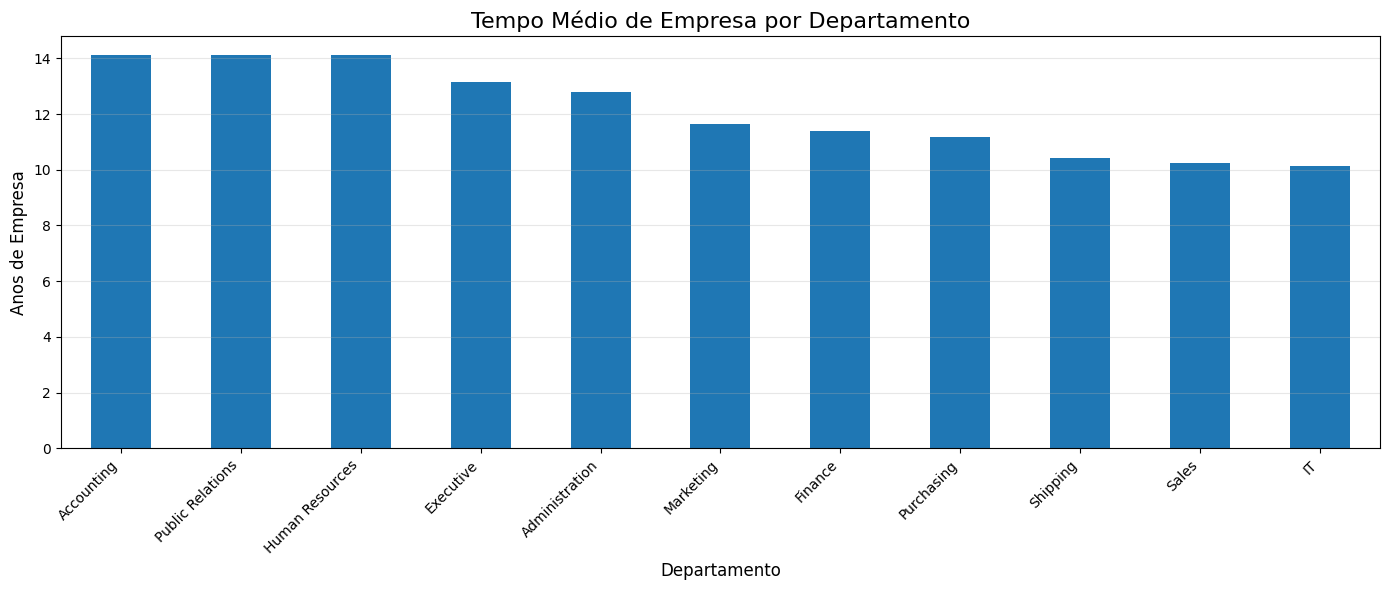

In [ ]:
# Gráfico - Tempo médio de empresa por departamento

plt.figure(figsize=(14,6))


tempo_departamento.plot(kind="bar")


plt.title("Tempo Médio de Empresa por Departamento",fontsize=16)
plt.xlabel("Departamento",fontsize=12)
plt.ylabel("Anos de Empresa",fontsize=12)
plt.xticks(rotation=45,ha="right")
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()

plt.savefig("../graficos/tempo_medio_departamento.png",dpi=300,bbox_inches="tight")

plt.show()

Análise..

A análise do tempo de empresa revelou que os 106 funcionários possuem uma média de permanência de aproximadamente 10,7 anos na organização. A baixa dispersão dos dados, com desvio padrão de 1,63 anos, indica que a empresa apresenta um quadro relativamente estável, sem grandes diferenças entre colaboradores mais recentes e mais antigos.

A análise por departamento demonstrou que áreas administrativas, como Accounting, Public Relations e Human Resources, apresentam os maiores tempos médios de permanência, próximos a 14 anos. Esse comportamento sugere maior estabilidade dessas equipes e possível retenção de conhecimento organizacional.

O departamento Executive também apresentou elevado tempo médio de empresa, indicando que os profissionais de liderança possuem longa trajetória dentro da organização, podendo representar uma estrutura de crescimento interno e valorização da experiência.

Por outro lado, departamentos como Sales e IT apresentaram menores tempos médios de permanência. No caso da área comercial, esse comportamento pode estar relacionado à maior dinâmica de mercado e necessidade de renovação frequente de profissionais.

A combinação entre tempo de empresa e análise salarial permite compreender não apenas quanto os funcionários recebem, mas também como experiência e permanência estão distribuídas dentro da estrutura organizacional.

In [74]:
# Correlação entre TEMPO_EMPRESA e SALARY

correlacao = (df_query1[["TEMPO_EMPRESA", "SALARY"]].corr())

correlacao

,TEMPO_EMPRESA,SALARY
TEMPO_EMPRESA,1.000000,0.419737
SALARY,0.419737,1.000000


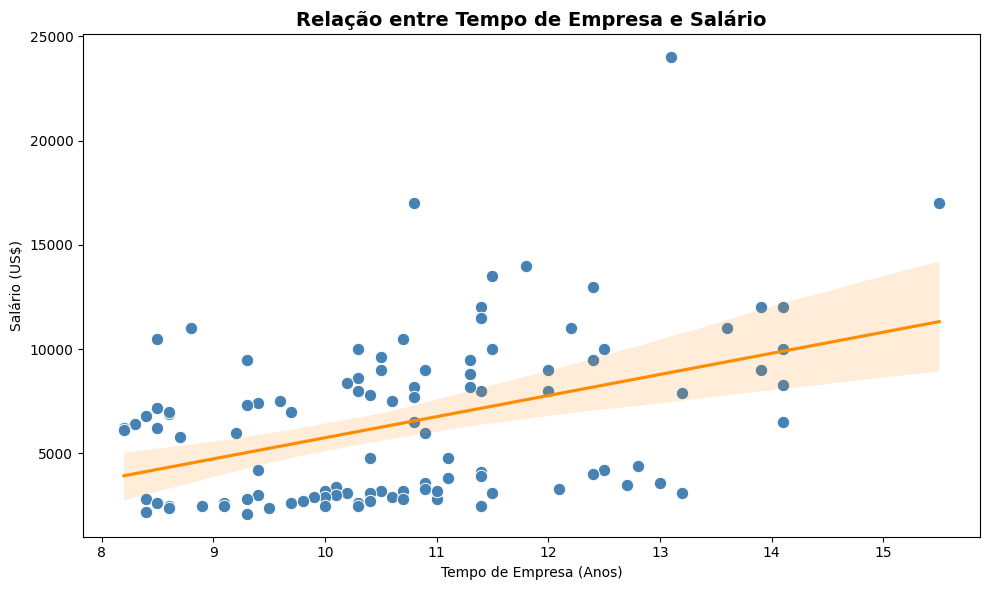


Matriz de Correlação:
               TEMPO_EMPRESA    SALARY
TEMPO_EMPRESA       1.000000  0.419737
SALARY              0.419737  1.000000


In [ ]:
# 1. Gráfico de Dispersão (Tempo de Empresa vs Salário)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_query1, x="TEMPO_EMPRESA", y="SALARY", color="steelblue", s=80)
sns.regplot(data=df_query1, x="TEMPO_EMPRESA", y="SALARY", scatter=False, color="darkorange") # Linha de tendência

plt.title("Relação entre Tempo de Empresa e Salário", fontsize=14, weight="bold")
plt.xlabel("Tempo de Empresa (Anos)")
plt.ylabel("Salário (US$)")

plt.tight_layout()

plt.savefig("../graficos/scatter_tempo_salario.png", dpi=300)

plt.show()

# 2. Correlação de Pearson

correlacao = df_query1[["TEMPO_EMPRESA", "SALARY"]].corr()

print("\nMatriz de Correlação:")
print(correlacao)